In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Définition du Line World sous la forme d'un Markov Decision Process

In [47]:
LINE_WORLD_LENGTH = 5

In [48]:
A = np.array([0, 1]) # 0: Gauche, 1: Droite

In [49]:
S = np.array([i for i in range(LINE_WORLD_LENGTH)]) # Agent position

In [50]:
R = np.array([0, -1, 1]) # Récompenses

In [51]:
p = np.zeros((len(S), len(A), len(S), len(R)))

p[1, 0, 0, 1] = 1.0
p[LINE_WORLD_LENGTH - 2, 1, LINE_WORLD_LENGTH - 1, 2] = 1.0

for s in range(2, LINE_WORLD_LENGTH - 1):
  p[s, 0, s - 1, 0] = 1.0

for s in range(1, LINE_WORLD_LENGTH - 2):
  p[s, 1, s + 1, 0] = 1.0

In [52]:
T = np.array([0, LINE_WORLD_LENGTH - 1]) # terminal states

# Policy Evaluation

In [53]:
def iterative_policy_evaluation(
    model_S: np.ndarray,
    model_A: np.ndarray,
    model_R: np.ndarray,
    model_p: np.ndarray,
    model_T: np.ndarray,
    pi: np.ndarray,
    gamma: float = 0.999999,
    theta: float = 0.000001):
  V = np.random.random(len(model_S))
  V[model_T] = 0.0
  while True:
    delta = 0
    for s_index in range(len(model_S)):
      v = V[model_S[s_index]]
      total = 0.0
      for a_index in range(len(model_A)):
        action_total = 0.0
        for s_p_index in range(len(model_S)):
          for r_index in range(len(model_R)):
            action_total += model_p[s_index, a_index, s_p_index, r_index] * (model_R[r_index] + gamma * V[s_p_index])
        total += pi[s_index, a_index] * action_total
      V[model_S[s_index]] = total
      delta = np.maximum(delta, np.abs((total - v)))
    if delta < theta:
      break
  return V

In [54]:
pi_right = np.zeros((len(S), len(A)))
pi_right[:, 1] = 1.0

In [55]:
iterative_policy_evaluation(S, A, R, p, T, pi_right)

array([0.      , 0.999998, 0.999999, 1.      , 0.      ])

In [56]:
pi_left = np.zeros((len(S), len(A)))
pi_left[:, 0] = 1.0

In [57]:
iterative_policy_evaluation(S, A, R, p, T, pi_left)

array([ 0.      , -1.      , -0.999999, -0.999998,  0.      ])

In [58]:
pi_uniform_random = np.zeros((len(S), len(A)))
pi_uniform_random[:, 0] = 0.5
pi_uniform_random[:, 1] = 0.5

In [59]:
iterative_policy_evaluation(S, A, R, p, T, pi_uniform_random)

array([ 0.0000000e+00, -4.9999942e-01,  5.8042106e-07,  5.0000029e-01,
        0.0000000e+00])

In [60]:
pi_mostly_right = np.zeros((len(S), len(A)))
pi_mostly_right[:, 0] = 0.2
pi_mostly_right[:, 1] = 0.8

In [61]:
iterative_policy_evaluation(S, A, R, p, T, pi_mostly_right)

array([0.        , 0.50588002, 0.88235112, 0.97647005, 0.        ])

In [62]:
0.999999 * 0.97647007 * 0.8 + 0.999999 * 0.50588027 * 0.2

0.88235122764789

# Policy Iteration

In [63]:
def policy_iteration(
    model_S: np.ndarray,
    model_A: np.ndarray,
    model_R: np.ndarray,
    model_p: np.ndarray,
    model_T: np.ndarray,
    gamma: float = 0.999999,
    theta: float = 0.000001):
  V = np.random.random(len(model_S))
  V[model_T] = 0.0
  pi = np.zeros((len(model_S), len(model_A)))
  for s_index in range(len(model_S)):
    rdm_a_index = np.random.randint(0, len(model_A))
    pi[s_index, rdm_a_index] = 1.0

  while True:
    # policy evaluation
    while True:
      delta = 0
      for s_index in range(len(model_S)):
        v = V[model_S[s_index]]
        total = 0.0
        for a_index in range(len(model_A)):
          action_total = 0.0
          for s_p_index in range(len(model_S)):
            for r_index in range(len(model_R)):
              action_total += model_p[s_index, a_index, s_p_index, r_index] * (model_R[r_index] + gamma * V[s_p_index])
          total += pi[s_index, a_index] * action_total
        V[model_S[s_index]] = total
        delta = np.maximum(delta, np.abs((total - v)))
      if delta < theta:
        break

    # policy improvement
    policy_stable = True
    for s_index in range(len(model_S)):
      old_a_index = np.argmax(pi[s_index])

      best_a_index = None
      best_a_score = 0.0

      for a_index in range(len(model_A)):
        total = 0
        for s_p_index in range(len(model_S)):
          for r_index in range(len(model_R)):
            total += model_p[s_index, a_index, s_p_index, r_index] * (model_R[r_index] + gamma * V[s_p_index])
        if best_a_index is None or total >= best_a_score:
          best_a_index = a_index
          best_a_score = total

      pi[s_index, :] = 0.0
      pi[s_index, best_a_index] = 1.0

      if old_a_index != best_a_index:
        policy_stable = False

    if policy_stable:
      break

  return pi, V

In [64]:
import time
t = time.time()
pi, v = policy_iteration(
    S, A, R, p, T
)
elapsed = time.time() - t
print(elapsed)
print(pi, v)

0.002966165542602539
[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]] [0.       0.999998 0.999999 1.       0.      ]


# Model Free Env Contrat

In [65]:
from typing import List

In [66]:
class ModelFreeEnv:
  def reset(self):
    raise NotImplementedError

  def step(self, action: int):
    raise NotImplementedError

  def is_game_over(self) -> bool:
    raise NotImplementedError

  def current_state(self) -> int:
    raise NotImplementedError

  def available_actions(self) -> List[int]:
    raise NotImplementedError

  def score(self) -> float:
    raise NotImplementedError

  # for performance reasons only
  def maximum_states_count(self) -> int:
    raise NotImplementedError

  def maximum_actions_count(self) -> int:
    raise NotImplementedError

  # optional
  def pretty_print(self):
    raise NotImplementedError



# Line World défini comme un ModelFreeEnv

In [67]:
class LineWorldEnv(ModelFreeEnv):
  def __init__(self, num_cells: int = 5):
    self.num_cells = num_cells
    self.agent_pos = num_cells // 2

  def reset(self):
    self.agent_pos = self.num_cells // 2

  def step(self, action: int):
    if action not in self.available_actions():
      raise Exception("Action is invalid in current state !!!")

    if self.is_game_over():
      raise Exception("Trying to play while game is over !!!")

    if action == 0:
      self.agent_pos -= 1
    elif action == 1:
      self.agent_pos += 1

  def is_game_over(self) -> bool:
    return self.agent_pos == 0 or self.agent_pos == self.num_cells - 1

  def current_state(self) -> int:
    return self.agent_pos

  def available_actions(self) -> List[int]:
    return [0, 1]

  def score(self) -> float:
    if self.agent_pos == 0:
      return -1.0
    elif self.agent_pos == self.num_cells - 1:
      return 1.0
    return 0.0

  # for performance reasons only
  def maximum_states_count(self) -> int:
    return self.num_cells

  def maximum_actions_count(self) -> int:
    return 2

  def pretty_print(self):
    for s in range(self.num_cells):
      if s == self.agent_pos:
        print("X", end="")
      else:
        print("_", end="")
    print()

In [68]:
env = LineWorldEnv()
env.pretty_print()

__X__


In [69]:
env.step(1)
env.pretty_print()

___X_


In [70]:
env.step(1)
env.pretty_print()

____X


In [71]:
env.score()

1.0

In [72]:
env.reset()
env.pretty_print()

__X__


# First Visit MonteCarlo Prediction

In [73]:
def first_visit_monte_carlo_prediction(
    env: ModelFreeEnv,
    pi: np.ndarray,
    iterations_count: int = 10_000,
    gamma: float = 0.999999
) -> np.ndarray:
  V = np.random.random(env.maximum_states_count())
  returns = [[] for s in range(env.maximum_states_count())]

  for it in range(iterations_count):
    env.reset()

    trajectory_states = []
    trajectory_actions = []
    trajectory_rewards = []

    while not env.is_game_over():
      s = env.current_state()
      a_probs = pi[s]
      a = np.random.choice(env.available_actions(), p=a_probs)

      prev_score = env.score()
      env.step(a)
      r = env.score() - prev_score

      trajectory_states.append(s)
      trajectory_actions.append(a)
      trajectory_rewards.append(r)

    V[env.current_state()] = 0.0

    G = 0
    for t, (s, a, r) in reversed(list(enumerate(zip(trajectory_states, trajectory_actions, trajectory_rewards)))):
      G = gamma * G + r
      if s not in trajectory_states[:t]:
        returns[s].append(G)
        V[s] = np.mean(returns[s])
  return V

In [74]:
def optimized_first_visit_monte_carlo_prediction(
    env: ModelFreeEnv,
    pi: np.ndarray,
    iterations_count: int = 10_000,
    gamma: float = 0.999999
) -> np.ndarray:
  V = np.random.random(env.maximum_states_count())
  V_counts = np.zeros(env.maximum_states_count())

  trajectory_states = []
  trajectory_actions = []
  trajectory_rewards = []

  for it in range(iterations_count):
    env.reset()

    trajectory_states.clear()
    trajectory_actions.clear()
    trajectory_rewards.clear()

    while not env.is_game_over():
      s = env.current_state()
      a_probs = pi[s]
      a = np.random.choice(env.available_actions(), p=a_probs)

      prev_score = env.score()
      env.step(a)
      r = env.score() - prev_score

      trajectory_states.append(s)
      trajectory_actions.append(a)
      trajectory_rewards.append(r)

    V[env.current_state()] = 0.0

    G = 0

    t = len(trajectory_states) - 1
    for s, a, r in zip(reversed(trajectory_states), reversed(trajectory_actions), reversed(trajectory_rewards)):
      G = gamma * G + r
      if s not in trajectory_states[:t]:
        V[s] = (V[s] * V_counts[s] + G) / (V_counts[s] + 1)
        V_counts[s] += 1
      t -= 1
  return V

In [75]:
start_time = time.time()
first_visit_monte_carlo_prediction(LineWorldEnv(), pi_right)
print("Elapsed : " + str(time.time() - start_time))

Elapsed : 8.252540111541748


In [76]:
start_time = time.time()
optimized_first_visit_monte_carlo_prediction(LineWorldEnv(), pi_right)
print("Elapsed : " + str(time.time() - start_time))

Elapsed : 0.532536506652832


In [77]:
first_visit_monte_carlo_prediction(LineWorldEnv(), pi_left)

array([ 0.        , -1.        , -0.999999  ,  0.64660844,  0.6278379 ])

In [78]:
first_visit_monte_carlo_prediction(LineWorldEnv(), pi_mostly_right)

array([0.        , 0.53468838, 0.88799827, 0.97675584, 0.        ])

# On Policy First Visit Monte Carlo Control

In [79]:
def optimized_on_policy_first_visit_monte_carlo_control(
    env: ModelFreeEnv,
    episodes_count: int = 10_000,
    gamma: float = 0.999999,
    epsilon: float = 0.05,
    cumulated_reward_per_step = None,
    max_steps: int = None,
) -> np.ndarray:
  Q = np.random.random((env.maximum_states_count(), env.maximum_actions_count()))
  Q_counts = np.zeros((env.maximum_states_count(), env.maximum_actions_count()))

  pi = np.ones((env.maximum_states_count(), env.maximum_actions_count())) / env.maximum_actions_count()

  total_steps = 0
  total_reward_from_start = 0.0

  trajectory_states = []
  trajectory_actions = []
  trajectory_rewards = []

  for it in range(episodes_count):
    if max_steps is not None  and total_steps >= max_steps:
      break

    env.reset()

    trajectory_states.clear()
    trajectory_actions.clear()
    trajectory_rewards.clear()

    while not env.is_game_over():
      if max_steps is not None  and total_steps >= max_steps:
        break

      s = env.current_state()
      a_probs = pi[s]
      a = np.random.choice(env.available_actions(), p=a_probs)

      prev_score = env.score()
      env.step(a)
      if max_steps is not None:
        total_steps += 1
      r = env.score() - prev_score
      if cumulated_reward_per_step is not None:
        total_reward_from_start += r
        cumulated_reward_per_step.append(total_reward_from_start)

      trajectory_states.append(s)
      trajectory_actions.append(a)
      trajectory_rewards.append(r)

    if env.is_game_over():
      Q[env.current_state(), :] = 0.0

    G = 0

    t = len(trajectory_states) - 1
    for s, a, r in zip(reversed(trajectory_states), reversed(trajectory_actions), reversed(trajectory_rewards)):
      G = gamma * G + r
      if (s, a) not in zip(trajectory_states[:t], trajectory_actions[:t]):
        Q[s, a] = (Q[s, a] * Q_counts[s, a] + G) / (Q_counts[s, a] + 1)
        Q_counts[s, a] += 1

        best_a = np.argmax(Q[s])
        pi[s, :] = epsilon / env.maximum_actions_count()
        pi[s, best_a] = 1 - epsilon + epsilon / env.maximum_actions_count()

      t -= 1
  return pi, Q

In [80]:
optimized_on_policy_first_visit_monte_carlo_control(LineWorldEnv())

(array([[0.5  , 0.5  ],
        [0.025, 0.975],
        [0.025, 0.975],
        [0.025, 0.975],
        [0.5  , 0.5  ]]),
 array([[ 0.        ,  0.        ],
        [-1.        ,  0.99999789],
        [ 0.97510068,  0.99999894],
        [ 0.99999787,  1.        ],
        [ 0.        ,  0.        ]]))

In [81]:
def choose_action_index_from_epsilon_greedy_policy(Q: np.ndarray, s: int, epsilon: float) -> int:
  if np.random.random() < epsilon:
    return np.random.choice(range(0, Q.shape[1]))

  return np.argmax(Q[s])


In [82]:
def create_epsilon_greedy_policy_from_Q(Q: np.ndarray, epsilon: float) -> np.ndarray:
  pi = np.zeros_like(Q)

  for (s, q_s) in enumerate(Q):
    best_a = np.argmax(q_s)
    pi[s, :] = epsilon / Q.shape[1]
    pi[s, best_a] += 1.0 - epsilon

  return pi


In [83]:
def sarsa(
    env: ModelFreeEnv,
    steps_count: int = 10_000,
    gamma: float = 0.999999,
    epsilon: float = 0.05,
    alpha: float = 0.1,
    cumulated_reward_per_step = None,
):
  Q = np.random.random((env.maximum_states_count(), env.maximum_actions_count()))

  total_steps = 0

  total_reward_from_start = 0.0

  # For each episode
  while total_steps < steps_count:
    env.reset()

    s = env.current_state()
    a = choose_action_index_from_epsilon_greedy_policy(Q, s, epsilon)

    while not env.is_game_over() and total_steps < steps_count:

      prev_score = env.score()
      env.step(a)

      total_steps += 1

      r = env.score() - prev_score
      if cumulated_reward_per_step is not None:
        total_reward_from_start += r
        cumulated_reward_per_step.append(total_reward_from_start)

      s_p = env.current_state()
      a_p = choose_action_index_from_epsilon_greedy_policy(Q, s_p, epsilon)

      Q[s, a] = (1.0 - alpha) * Q[s, a] + alpha * (r + gamma * Q[s_p, a_p])

      s = s_p
      a = a_p

    if env.is_game_over():
      Q[s, :] = 0.0

  return create_epsilon_greedy_policy_from_Q(Q, epsilon), Q



In [84]:
print(sarsa(LineWorldEnv(), 500_000))

(array([[0.975, 0.025],
       [0.025, 0.975],
       [0.025, 0.975],
       [0.025, 0.975],
       [0.975, 0.025]]), array([[ 0.        ,  0.        ],
       [-0.99999996,  0.99996939],
       [ 0.9868737 ,  0.999999  ],
       [ 0.99994227,  1.        ],
       [ 0.        ,  0.        ]]))


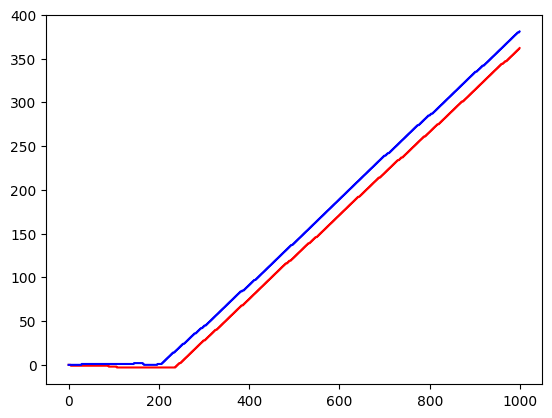

In [85]:
steps = 1000

on_policy_monte_carlo_control_rewards = []
sarsa_rewards = []

optimized_on_policy_first_visit_monte_carlo_control(LineWorldEnv(),
                                                    99999999999,
                                                    cumulated_reward_per_step=on_policy_monte_carlo_control_rewards,
                                                    max_steps=steps)

sarsa(LineWorldEnv(),
      steps,
      cumulated_reward_per_step=sarsa_rewards)

plt.plot(list(range(steps)), on_policy_monte_carlo_control_rewards, c='red')
plt.plot(list(range(steps)), sarsa_rewards, c='blue')
plt.show()

# Contrat d'environnement pour les algorithmes de Deep RL :

In [86]:
class DeepModelFreeEnv:
  def reset(self):
    raise NotImplementedError

  def step(self, action: int):
    raise NotImplementedError

  def is_game_over(self) -> bool:
    raise NotImplementedError

  def obs(self) -> np.ndarray:
    raise NotImplementedError

  def available_actions(self) -> List[int]:
    raise NotImplementedError

  def score(self) -> float:
    raise NotImplementedError

  # For performance reasons
  def obs_dim(self) -> int:
    raise NotImplementedError

  def max_actions_count(self) -> int:
    raise NotImplementedError

  def pretty_print(self):
    raise NotImplementedError

In [87]:
import tensorflow as tf
import keras

# Définition du LineWorld sous la forme d'un DeepModelFreeEnv

In [88]:
class DeepLineWorldEnv(DeepModelFreeEnv):
  def __init__(self, num_cells: int = 5):
    self.num_cells = num_cells
    self.agent_pos = self.num_cells // 2

  def reset(self):
    self.agent_pos = self.num_cells // 2

  def step(self, action: int):
    if action not in self.available_actions():
      raise Exception("Invalid action in current state !!!")

    if self.is_game_over():
      raise Exception("Agent is trying to play while game is over !!!")

    if action == 0:
      self.agent_pos -= 1
    elif action == 1:
      self.agent_pos += 1

  def is_game_over(self) -> bool:
    return self.agent_pos == 0 or self.agent_pos == self.num_cells - 1

  # One hot encoding (it's not great here ...)
  def obs(self) -> np.ndarray:
    obs = np.zeros(self.num_cells)
    obs[self.agent_pos] = 1.0

    return obs

  def available_actions(self) -> List[int]:
    return [0, 1] # 0 : Gauche, 1 : Droite

  def score(self) -> float:
    if self.agent_pos == 0:
      return -1.0
    elif self.agent_pos == self.num_cells - 1:
      return 1.0
    return 0.0

  # For performance reasons
  def obs_dim(self) -> int:
    return self.num_cells

  def max_actions_count(self) -> int:
    return 2

  def pretty_print(self):
    for s in range(0, self.num_cells):
      if s == self.agent_pos:
        print("X", end="")
      else:
        print("_", end="")
    print()

In [89]:
def choose_action_epsilon_greedy_from_keras_q_model(q_model: keras.models.Model,
                                                    epsilon: float,
                                                    obs: np.ndarray,
                                                    available_actions: List[int],
                                                    max_actions_count: int):
  if np.random.random() < epsilon:
      a = np.random.choice(available_actions)
  else:
      best_q_s_a = 0.0
      best_a = None
      for a in available_actions:
        a_description = np.zeros(max_actions_count)
        a_description[a] = 1.0

        obs_and_a_desc = np.concat([obs, a_description])

        q_s_a = q_model.predict(np.array([obs_and_a_desc]), verbose=None)[0][0]

        if best_a is None or q_s_a >= best_q_s_a:
          best_a = a
          best_q_s_a = q_s_a

      a = best_a
  return a

In [90]:
def episodic_semigradient_sarsa(
    env: DeepModelFreeEnv,
    alpha: float = 0.003,
    epsilon: float = 0.05,
    gamma:float = 0.99999,
    steps_count: int = 30_000
):
  q_model = keras.models.Sequential()
  q_model.add(keras.layers.Dense(1, activation=keras.activations.linear))

  total_steps = 0
  total_loss = 0.0

  # For each episode
  while total_steps < steps_count:
    env.reset()

    # s description
    obs = env.obs()

    a = choose_action_epsilon_greedy_from_keras_q_model(q_model,
                                                    epsilon,
                                                    obs,
                                                    env.available_actions(),
                                                    env.max_actions_count())

    while not env.is_game_over() and total_steps < steps_count:
      a_description = np.zeros(env.max_actions_count())
      a_description[a] = 1.0
      prev_score = env.score()
      env.step(a)
      total_steps += 1
      r = env.score() - prev_score

      # s'
      obs_p = env.obs()

      if env.is_game_over():
        q_s_p_a_p = 0.0
      else:
        a_p = choose_action_epsilon_greedy_from_keras_q_model(q_model,
                                                    epsilon,
                                                    obs_p,
                                                    env.available_actions(),
                                                    env.max_actions_count())
        a_p_description = np.zeros(env.max_actions_count())
        a_p_description[a_p] = 1.0
        obs_p_a_p = np.concatenate([obs_p, a_p_description])
        q_s_p_a_p = q_model.predict(np.array([obs_p_a_p]), verbose=None)[0][0]

      q_target = r + gamma * q_s_p_a_p

      with tf.GradientTape() as tape:
        obs_and_a = np.concatenate([obs, a_description])
        q_s_a = q_model(np.array([obs_and_a]))[0][0]
        loss = (q_target - q_s_a) ** 2.0

      total_loss += loss
      if total_steps % 10 == 0:
        print(total_loss / 10)
        total_loss = 0.0
      grads = tape.gradient(q_s_a, q_model.trainable_variables)
      for (w, grad) in zip(q_model.trainable_variables, grads):
        w.assign_add(alpha * (q_target - q_s_a) * grad)

      obs = obs_p
      a = a_p

  return q_model

In [93]:
model = episodic_semigradient_sarsa(DeepLineWorldEnv(), steps_count = 1000)

tf.Tensor(0.2213823, shape=(), dtype=float32)
tf.Tensor(0.21501446, shape=(), dtype=float32)
tf.Tensor(0.20897916, shape=(), dtype=float32)
tf.Tensor(0.20323369, shape=(), dtype=float32)
tf.Tensor(0.19774066, shape=(), dtype=float32)
tf.Tensor(0.19246754, shape=(), dtype=float32)
tf.Tensor(0.18738618, shape=(), dtype=float32)
tf.Tensor(0.18247224, shape=(), dtype=float32)
tf.Tensor(0.5760189, shape=(), dtype=float32)
tf.Tensor(0.4209202, shape=(), dtype=float32)
tf.Tensor(0.1650045, shape=(), dtype=float32)
tf.Tensor(0.16068122, shape=(), dtype=float32)
tf.Tensor(0.15644948, shape=(), dtype=float32)
tf.Tensor(0.1670058, shape=(), dtype=float32)
tf.Tensor(0.15047523, shape=(), dtype=float32)
tf.Tensor(0.16784537, shape=(), dtype=float32)
tf.Tensor(0.14473195, shape=(), dtype=float32)
tf.Tensor(0.16727123, shape=(), dtype=float32)
tf.Tensor(0.29241797, shape=(), dtype=float32)
tf.Tensor(0.13482913, shape=(), dtype=float32)
tf.Tensor(0.131013, shape=(), dtype=float32)
tf.Tensor(0.1664027,

In [94]:
model.trainable_variables

[<Variable path=sequential_1/dense_1/kernel, shape=(7, 1), dtype=float32, value=[[-0.13732219]
  [ 0.6749373 ]
  [ 0.40524006]
  [ 0.47282696]
  [ 0.84172183]
  [-0.5087069 ]
  [ 0.4301665 ]]>,
 <Variable path=sequential_1/dense_1/bias, shape=(1,), dtype=float32, value=[0.18473545]>]